In [1]:
%load_ext autoreload
%autoreload 2

**Author:** Salvador Navas  
**Date:** 2025-06-27

In [2]:
from pyhydra.climate.time_series import (
    # extraction
    extract_block_maxima,
    extract_pot,
    threshold_stability_plot,
    # GEV fitting
    fit_gev,
    fit_gev_map,
    fit_gev_fisher,
    fit_gev_mcmc,
    # GPD fitting
    fit_gpd,
    # return levels
    return_level_gev,
    return_level_gpd,
    return_levels,
    return_level_ci,
    # diagnostics
    plot_return_levels,
    plot_diagnostic,
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import genextreme

# Extreme Value Analysis

Two complementary approaches for estimating flood or rainfall frequency:

| Method | Distribution | Data | Best for |
|--------|-------------|------|----------|
| **Block Maxima** | GEV | Annual/seasonal maxima | Long records (≥ 25 yr) |
| **Peaks Over Threshold** | GPD | All peaks above threshold | Short records; data-efficient |

### Installation
```bash
pip install scipy lmoments3          # MLE + L-moments
conda install -c conda-forge pymc    # full MCMC (optional)
```

### Robust fitting strategy
1. MLE with L-moments warm-start and bounded shape parameter `xi ∈ [-0.5, 0.5]`.
2. If MLE fails: L-moment estimate (always stable).
3. Bayesian MAP (fast, weakly informative priors) — no MCMC needed.
4. Full MCMC (pymc) for complete posterior uncertainty.

---
## Synthetic dataset

60 years of synthetic daily discharge with seasonal variability.

In [3]:
rng = np.random.default_rng(42)
dates = pd.date_range("1960-01-01", "2019-12-31", freq="D")
n = len(dates)

# Seasonal base flow
doy = dates.dayofyear
base = 50 + 80 * np.sin(2 * np.pi * (doy / 365 - 0.1))
base = np.clip(base, 10, None)

# Add flood events (Poisson arrivals, Pareto magnitudes)
n_events = rng.poisson(12, n // 30)   # ~12 events/month across 30-day windows
flood_signal = np.zeros(n)
for _ in range(int(n * 0.03)):        # sparse large events
    day = rng.integers(0, n)
    duration = rng.integers(3, 20)
    peak = rng.pareto(1.5) * 300 + 200
    end = min(day + duration, n)
    t_evt = np.arange(end - day)
    flood_signal[day:end] += peak * np.exp(-t_evt / (duration / 3))

noise = rng.exponential(20, n)
Q = base + flood_signal + noise
Q = np.clip(Q, 5, None)
discharge = pd.Series(Q, index=dates, name="Q (m³/s)")

print(f"Period : {dates[0].date()} → {dates[-1].date()}  ({len(dates)} days)")
print(f"Mean   : {discharge.mean():.1f} m³/s")
print(f"Std    : {discharge.std():.1f} m³/s")
print(f"Max    : {discharge.max():.1f} m³/s")

Period : 1960-01-01 → 2019-12-31  (21915 days)
Mean   : 155.3 m³/s
Std    : 284.7 m³/s
Max    : 7610.1 m³/s


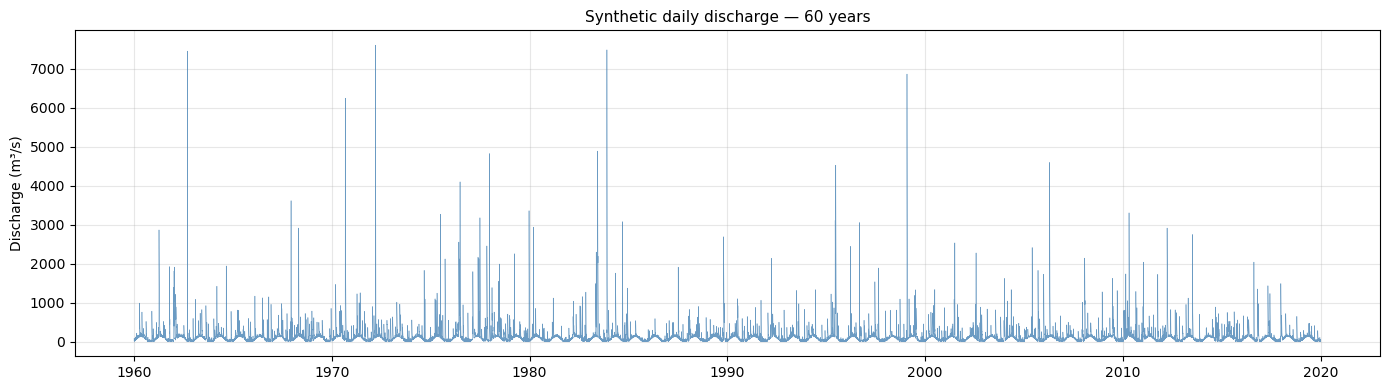

In [4]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(discharge.index, discharge.values, lw=0.4, color="steelblue", alpha=0.8)
ax.set_ylabel("Discharge (m³/s)")
ax.set_title("Synthetic daily discharge — 60 years", fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 1. Block Maxima — GEV

Extract one maximum per year and fit a GEV distribution.

Annual maxima: 60 values
Range: 479 – 7610 m³/s


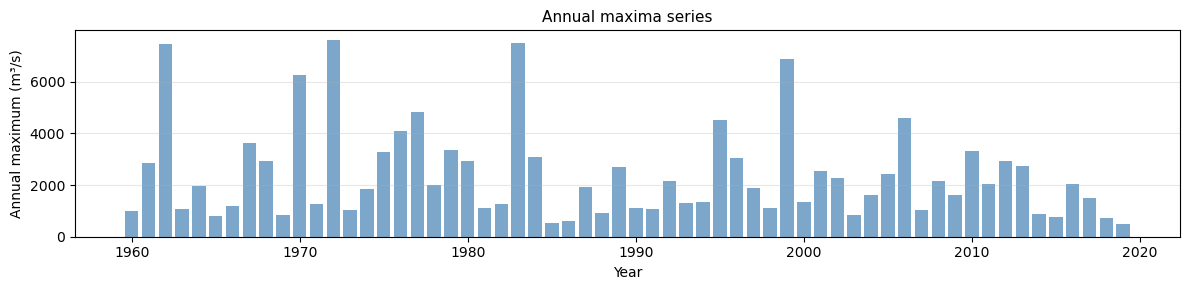

In [5]:
annual_max = extract_block_maxima(discharge, freq="YE")
print(f"Annual maxima: {len(annual_max)} values")
print(f"Range: {annual_max.min():.0f} – {annual_max.max():.0f} m³/s")

fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(annual_max.index.year, annual_max.values, color="steelblue", alpha=0.7)
ax.set_xlabel("Year")
ax.set_ylabel("Annual maximum (m³/s)")
ax.set_title("Annual maxima series", fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# Fit GEV — both MLE and L-moments
params_gev = fit_gev(annual_max.values, method="both")
print("GEV MLE:")
if "error" not in params_gev["mle"]:
    p = params_gev["mle"]
    print(f"  mu = {p['mu']:.1f}  sigma = {p['sigma']:.1f}  xi = {p['xi']:.4f}")

print("\nGEV L-moments:")
try:
    p = params_gev["lmom"]
    print(f"  mu = {p['mu']:.1f}  sigma = {p['sigma']:.1f}  xi = {p['xi']:.4f}")
except Exception:
    print("  (lmoments3 not installed — pip install lmoments3)")

params_best = params_gev.get("mle") or params_gev.get("lmom")

GEV MLE:
  mu = 1433.9  sigma = 877.5  xi = 0.4247

GEV L-moments:
  mu = 1504.3  sigma = 1007.1  xi = -0.2445


In [7]:
# Return levels table
T_values = [2, 5, 10, 25, 50, 100, 200, 500, 1000]
rl_gev = return_levels(params_best, T_values, dist="gev")
print("GEV return levels (m³/s):")
print(pd.DataFrame({"T (years)": T_values, "Return level (m³/s)": rl_gev.values.round(0)}).to_string(index=False))

GEV return levels (m³/s):
 T (years)  Return level (m³/s)
         2               1782.0
         5               3274.0
        10               4741.0
        25               7405.0
        50              10204.0
       100              13944.0
       200              18955.0
       500              28292.0
      1000              38202.0


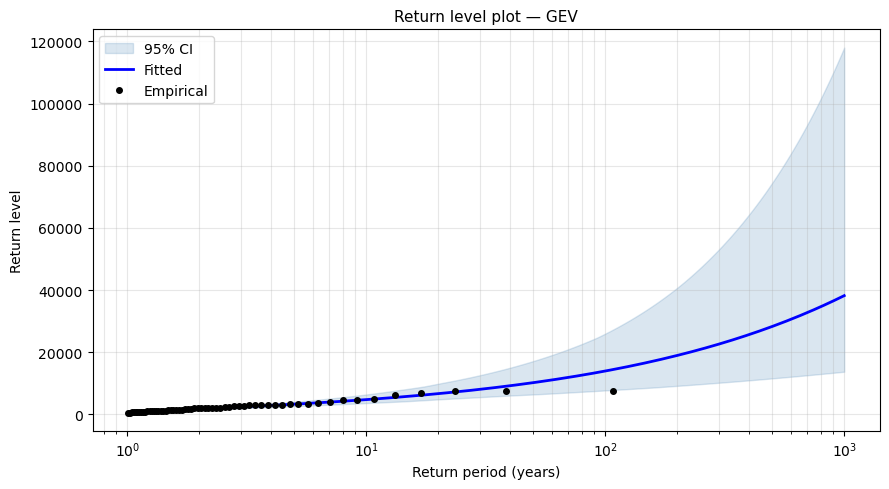

In [8]:
# Return level plot with 95% bootstrap CI
fig, ax = plt.subplots(figsize=(9, 5))
plot_return_levels(annual_max.values, params_best, dist="gev",
                   n_bootstrap=100, ax=ax)
plt.tight_layout()
plt.show()

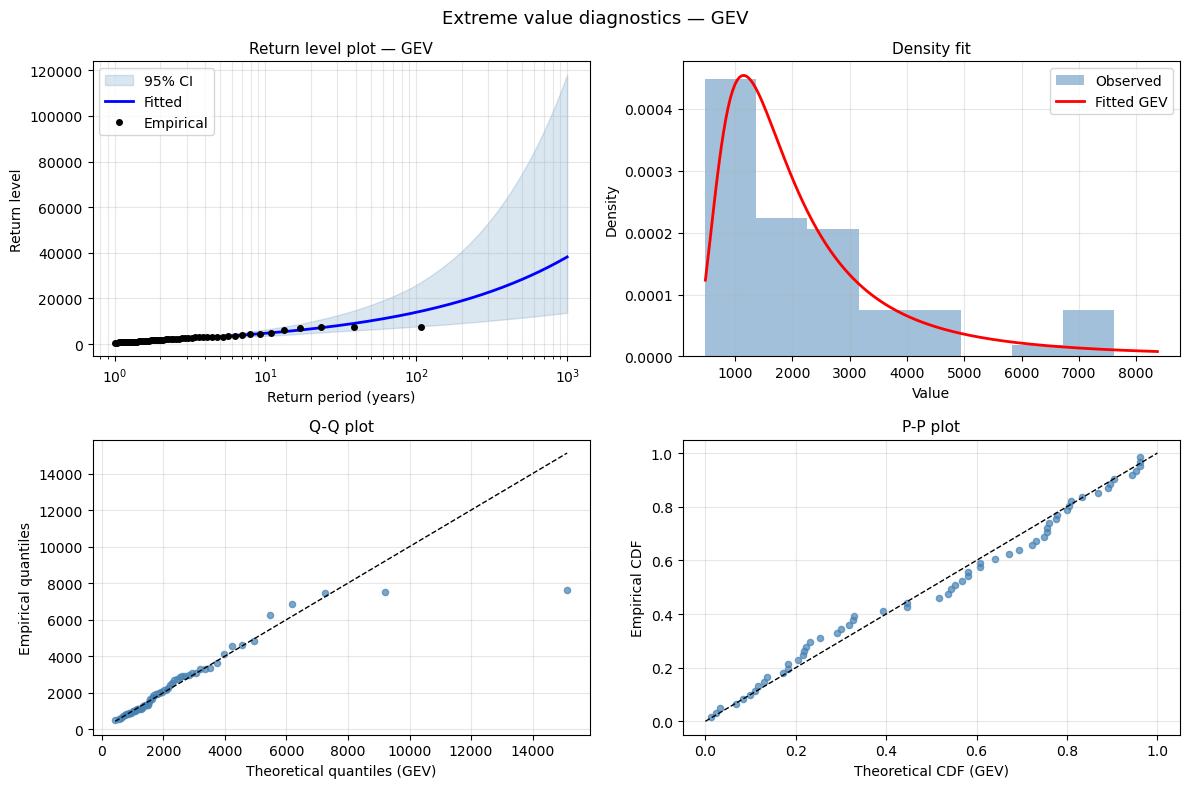

In [9]:
# Full 2×2 diagnostic panel
fig = plot_diagnostic(annual_max.values, params_best, dist="gev")
plt.show()

---
## 2. Bootstrap confidence intervals

`return_level_ci` gives (point, lower, upper) for any return period
without assuming a parametric sampling distribution.

In [10]:
print(f"{'T':>6}  {'Point':>8}  {'Lower (95%)':>11}  {'Upper (95%)':>11}")
for T in [10, 50, 100]:
    pt, lo, hi = return_level_ci(
        annual_max.values, T=T, dist="gev",
        method="mle", n_bootstrap=100, ci=0.95
    )
    print(f"{T:>6}  {pt:>8.0f}  {lo:>11.0f}  {hi:>11.0f}")

     T     Point  Lower (95%)  Upper (95%)


    10      4741         3627         6393


    50     10204         6409        17153


   100     13944         7698        25985


---
## 3. Peaks Over Threshold — GPD

### 3.1 Threshold selection

A good threshold minimises sampling variance (enough exceedances)
while satisfying the GPD asymptotic assumption (threshold high enough).
The stability plot shows where the estimated GPD shape and mean excess
become approximately constant — that is the target range.

In [11]:
stab = threshold_stability_plot(discharge, min_peaks=15)
stab.head(10)

,threshold,n_exceed,mean_excess,gpd_shape,gpd_scale
0,101.658123,10957,162.233857,0.606441,69.289399
1,103.937863,10738,163.238140,0.624928,67.959829
2,106.330087,10519,164.218939,0.646549,66.393823
3,108.666509,10300,165.349660,0.668519,64.907001
4,111.091538,10081,166.489242,0.694602,63.122935
5,113.398449,9862,167.854229,0.719637,61.592547
6,115.790623,9643,169.248064,0.749298,59.767728
7,117.966278,9424,170.980127,0.775160,58.456279
8,120.051056,9204,172.956845,0.799874,57.377348
9,122.178773,8985,175.018373,0.827635,56.159547


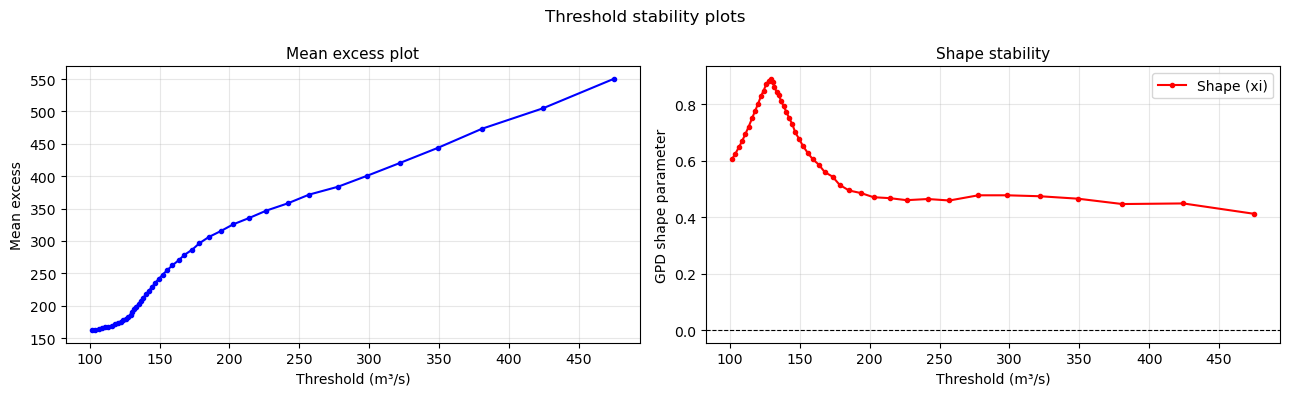

Selected threshold: 475 m³/s  (1096 exceedances)


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(stab.threshold, stab.mean_excess, "b-o", ms=3)
axes[0].set_xlabel("Threshold (m³/s)")
axes[0].set_ylabel("Mean excess")
axes[0].set_title("Mean excess plot", fontsize=11)
axes[0].grid(alpha=0.3)

axes[1].plot(stab.threshold, stab.gpd_shape, "r-o", ms=3, label="Shape (xi)")
axes[1].axhline(0, ls="--", color="k", lw=0.8)
axes[1].set_xlabel("Threshold (m³/s)")
axes[1].set_ylabel("GPD shape parameter")
axes[1].set_title("Shape stability", fontsize=11)
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("Threshold stability plots", fontsize=12)
plt.tight_layout()
plt.show()

# Choose a threshold where shape becomes stable
threshold = float(stab[stab.n_exceed >= 50].threshold.iloc[-1])
print(f"Selected threshold: {threshold:.0f} m³/s  "
      f"({stab[stab.threshold == threshold].n_exceed.values[0]:.0f} exceedances)")

### 3.2 GPD fitting

In [13]:
params_gpd = fit_gpd(discharge, threshold=threshold, method="mle", min_gap=7)
print("GPD parameters:")
print(f"  scale        = {params_gpd['scale']:.2f}")
print(f"  shape (xi)   = {params_gpd['shape']:.4f}")
print(f"  threshold    = {params_gpd['threshold']:.0f} m³/s")
print(f"  n exceedances= {params_gpd['n_exceed']}")
print(f"  lambda rate  = {params_gpd['lambda_rate']:.2f} peaks/year")

GPD parameters:
  scale        = 396.29
  shape (xi)   = 0.4976
  threshold    = 475 m³/s
  n exceedances= 297
  lambda rate  = 4.95 peaks/year


In [14]:
# Return levels table
rl_gpd = return_levels(params_gpd, T_values, dist="gpd")
print("GPD return levels (m³/s):")
print(pd.DataFrame({"T (years)": T_values, "Return level (m³/s)": rl_gpd.values.round(0)}).to_string(index=False))

GPD return levels (m³/s):
 T (years)  Return level (m³/s)
         2               2171.0
         5               3611.0
        10               5230.0
        25               8437.0
        50              12045.0
       100              17139.0
       200              24331.0
       500              38573.0
      1000              54594.0


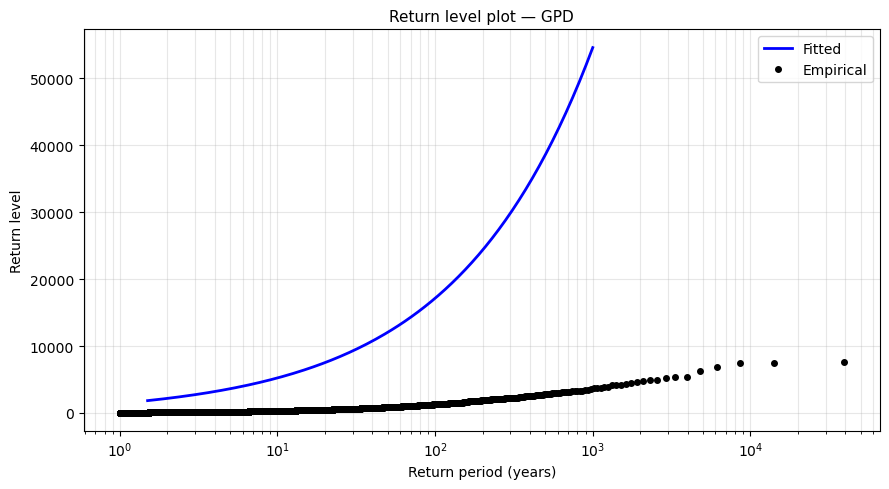

In [15]:
# Return level plot
fig, ax = plt.subplots(figsize=(9, 5))
plot_return_levels(discharge, params_gpd, dist="gpd", n_bootstrap=100, ax=ax)
plt.tight_layout()
plt.show()

---
## 4. GEV vs GPD comparison

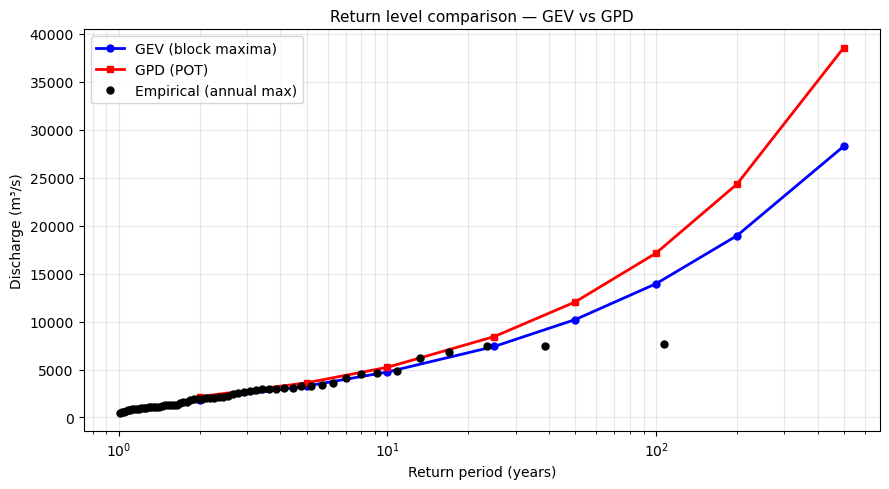

 T (years)  GEV (m³/s)  GPD (m³/s)  Diff (%)
         2      1782.0      2171.0      21.8
         5      3274.0      3611.0      10.3
        10      4741.0      5230.0      10.3
        25      7405.0      8437.0      13.9
        50     10204.0     12045.0      18.0
       100     13944.0     17139.0      22.9
       200     18955.0     24331.0      28.4
       500     28292.0     38573.0      36.3


In [16]:
T_comp = [2, 5, 10, 25, 50, 100, 200, 500]
rl_gev_vals = [return_level_gev(params_best, T) for T in T_comp]
rl_gpd_vals = [return_level_gpd(params_gpd, T) for T in T_comp]

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogx(T_comp, rl_gev_vals, "b-o", lw=2, ms=5, label="GEV (block maxima)")
ax.semilogx(T_comp, rl_gpd_vals, "r-s", lw=2, ms=5, label="GPD (POT)")

# Empirical from annual maxima
arr_sorted = np.sort(annual_max.values)
n = len(arr_sorted)
prob = (np.arange(1, n + 1) - 0.44) / (n + 0.12)
ax.semilogx(1 / (1 - prob), arr_sorted, "ko", ms=5, label="Empirical (annual max)")

ax.set_xlabel("Return period (years)")
ax.set_ylabel("Discharge (m³/s)")
ax.set_title("Return level comparison — GEV vs GPD", fontsize=11)
ax.legend()
ax.grid(which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# Numerical comparison
comparison = pd.DataFrame({
    "T (years)": T_comp,
    "GEV (m³/s)": np.round(rl_gev_vals, 0),
    "GPD (m³/s)": np.round(rl_gpd_vals, 0),
    "Diff (%)": np.round(
        100 * (np.array(rl_gpd_vals) - np.array(rl_gev_vals)) / np.array(rl_gev_vals), 1
    ),
})
print(comparison.to_string(index=False))

---
## 5. Bayesian GEV

### 5.1 MAP estimation (fast, no MCMC)

Uses weakly informative priors and scipy's Nelder-Mead optimiser.
Regularises the shape parameter estimate — useful for short records.

In [17]:
params_map = fit_gev_map(annual_max.values)
print("Bayesian MAP:")
print(f"  mu    = {params_map['mu']:.1f}")
print(f"  sigma = {params_map['sigma']:.1f}")
print(f"  xi    = {params_map['xi']:.4f}")
print(f"  log-posterior = {params_map['map_logpost']:.2f}")

print("\nComparison MLE vs MAP:")
print(f"  {'':10} {'MLE':>10} {'MAP':>10}")
for key in ['mu', 'sigma', 'xi']:
    mle_val = params_best.get(key, float('nan'))
    map_val = params_map[key]
    print(f"  {key:10} {mle_val:>10.2f} {map_val:>10.2f}")

Bayesian MAP:
  mu    = 1499.9
  sigma = 936.1
  xi    = 0.3346
  log-posterior = -526.37

Comparison MLE vs MAP:
                    MLE        MAP
  mu            1433.88    1499.93
  sigma          877.45     936.13
  xi               0.42       0.33


In [18]:
# Short record demonstration — MAP vs MLE comparison
short_record = annual_max.values[:15]   # only 15 years

try:
    params_mle_short = fit_gev(short_record, method="mle")
except RuntimeError:
    params_mle_short = fit_gev(short_record, method="lmom")
params_map_short = fit_gev_map(short_record)

print("\nShort record (15 years) — return levels at T=100:")
print(f"  MLE: {return_level_gev(params_mle_short, 100):.0f} m³/s  "
      f"xi = {params_mle_short['xi']:.3f}")
print(f"  MAP: {return_level_gev(params_map_short, 100):.0f} m³/s  "
      f"xi = {params_map_short['xi']:.3f}  (prior pulls xi toward 0)")


Short record (15 years) — return levels at T=100:
  MLE: 4083 m³/s  xi = -0.359
  MAP: 15182 m³/s  xi = 0.349  (prior pulls xi toward 0)


### 5.2 Full MCMC posterior (pymc)

The full posterior gives a distribution over return levels — useful when
the record is short and parameter uncertainty is large.

```bash
conda install -c conda-forge pymc
```

In [19]:
# Full MCMC posterior via pystan (non-centered parameterisation)
# Uses 2 chains / 500 samples for speed; use 4 chains / 2000 for production.
posterior = fit_gev_mcmc(annual_max.values, n_samples=500, n_chains=2, adapt_delta=0.90)
print("MCMC posterior summary (mu, sigma, xi):")
print(posterior.describe().round(1))


Building...

Building: found in cache, done.

Messages from stanc:


Warning in '/var/folders/44/dw7p6q9108xcc4mmh_f7q1vc0000gn/T/httpstan_5cuft2oc/model_i7affbtg.stan', line 24, column 12: A
    control flow statement depends on parameter(s): mu_raw, sigma, xi.
Warning in '/var/folders/44/dw7p6q9108xcc4mmh_f7q1vc0000gn/T/httpstan_5cuft2oc/model_i7affbtg.stan', line 22, column 8: A
    control flow statement depends on parameter(s): xi.
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.


Sampling:   0%

...

warn:  Stan can't start sampling from this initial value.


  Gradient evaluation took 1.4e-05 seconds


  1000 transitions using 10 leapfrog steps per transition would take 0.14 seconds.


  Adjust your expectations accordingly!


MCMC posterior summary (mu, sigma, xi):
           mu   sigma      xi
count  1000.0  1000.0  1000.0
mean   1471.5   946.3     0.4
std     137.5   134.6     0.1
min    1028.7   602.6     0.0
25%    1378.8   853.9     0.3
50%    1468.9   942.7     0.4
75%    1561.6  1031.7     0.5
max    1916.6  1430.5     0.9


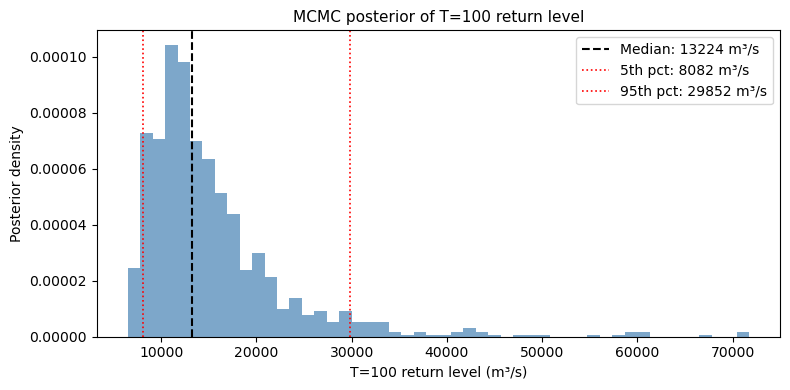


T=100 return level:
  Median : 13224 m³/s
  90% CI : [8082, 29852] m³/s


In [20]:
# Posterior distribution of the T=100 return level.
# Each MCMC sample is a plausible parameter set → a distribution over return levels.
T_post = 100
rl_posterior = np.array([
    return_level_gev({'mu': r['mu'], 'sigma': r['sigma'], 'xi': r['xi']}, T_post)
    for _, r in posterior.iterrows()
])
# Remove extreme tails (xi > 0.5 can produce very large extrapolations)
rl_posterior = rl_posterior[np.isfinite(rl_posterior) & (rl_posterior < 1e6)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(rl_posterior, bins=50, density=True, color="steelblue", alpha=0.7)
ax.axvline(np.median(rl_posterior), color="k", ls="--", lw=1.5,
           label=f"Median: {np.median(rl_posterior):.0f} m³/s")
ax.axvline(np.quantile(rl_posterior, 0.05), color="r", ls=":", lw=1.2,
           label=f"5th pct: {np.quantile(rl_posterior, 0.05):.0f} m³/s")
ax.axvline(np.quantile(rl_posterior, 0.95), color="r", ls=":", lw=1.2,
           label=f"95th pct: {np.quantile(rl_posterior, 0.95):.0f} m³/s")
ax.set_xlabel(f"T={T_post} return level (m³/s)")
ax.set_ylabel("Posterior density")
ax.set_title(f"MCMC posterior of T={T_post} return level", fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nT={T_post} return level:")
print(f"  Median : {np.median(rl_posterior):.0f} m³/s")
print(f"  90% CI : [{np.quantile(rl_posterior, 0.05):.0f}, {np.quantile(rl_posterior, 0.95):.0f}] m³/s")


---
## 6. Seasonal analysis

Extract seasonal maxima and fit a GEV per season — useful when flood
generating mechanisms differ between seasons.

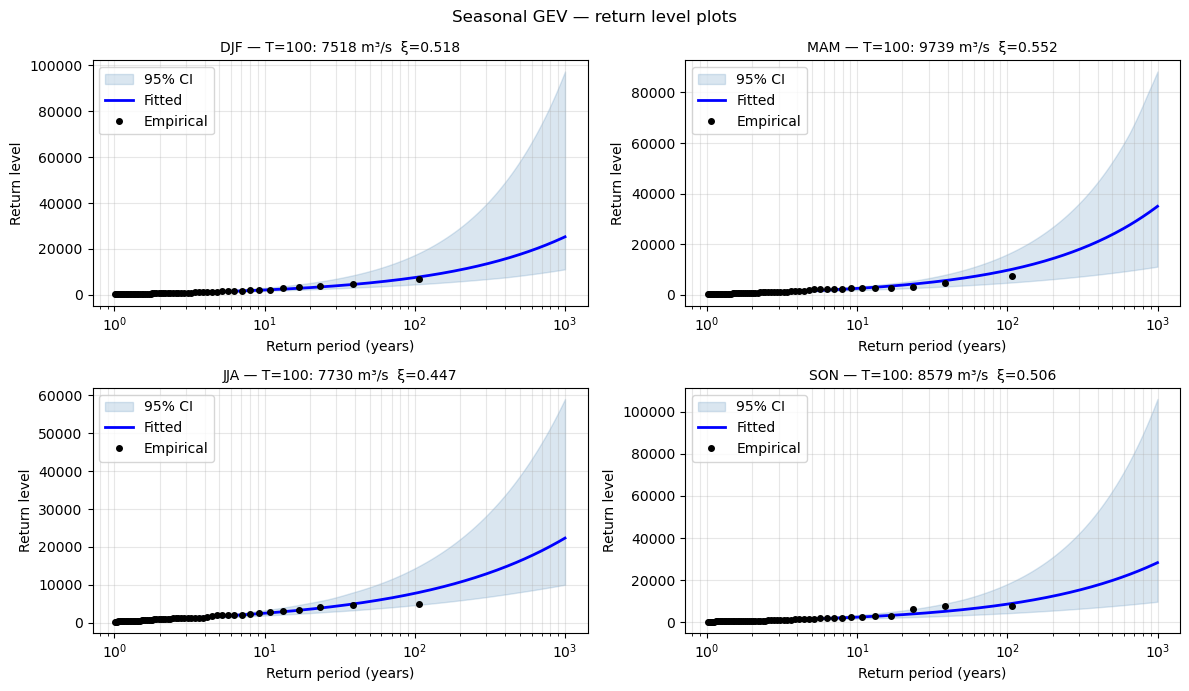

In [21]:
# Seasonal maxima using quarterly blocks
seasonal_max = discharge.groupby(discharge.index.to_period('Q')).max()

# Assign calendar season labels
season_map = {12: 'DJF', 1: 'DJF', 2: 'DJF',
              3: 'MAM', 4: 'MAM', 5: 'MAM',
              6: 'JJA', 7: 'JJA', 8: 'JJA',
              9: 'SON', 10: 'SON', 11: 'SON'}
discharge_df = discharge.to_frame()
discharge_df['season'] = discharge.index.month.map(season_map)

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
T_ref = 100

for ax, season in zip(axes.ravel(), ['DJF', 'MAM', 'JJA', 'SON']):
    season_series = discharge_df[discharge_df.season == season].iloc[:, 0]
    if len(season_series) == 0:
        continue
    seas_am = extract_block_maxima(season_series, freq='YE')
    if len(seas_am) < 5:
        ax.set_title(f"{season} — insufficient data"); continue

    try:
        p = fit_gev(seas_am.values, method='mle')
        rl = return_level_gev(p, T_ref)
        plot_return_levels(seas_am.values, p, dist='gev', n_bootstrap=50, ax=ax)
        ax.set_title(f"{season} — T={T_ref}: {rl:.0f} m³/s  ξ={p['xi']:.3f}", fontsize=10)
    except Exception as e:
        ax.set_title(f"{season} — fit failed: {e}", fontsize=9)

plt.suptitle("Seasonal GEV — return level plots", fontsize=12)
plt.tight_layout()
plt.show()

---
## 7. Non-stationarity check

A simple trend check on annual maxima — if the Mann-Kendall test is
significant, a non-stationary GEV (trend in location parameter) may be
more appropriate.

Mann-Kendall: tau = -0.098  p = 0.267
Linear trend: slope = -22.17 m³/s/year  p = 0.099
→ No significant trend — stationary GEV/GPD is appropriate.


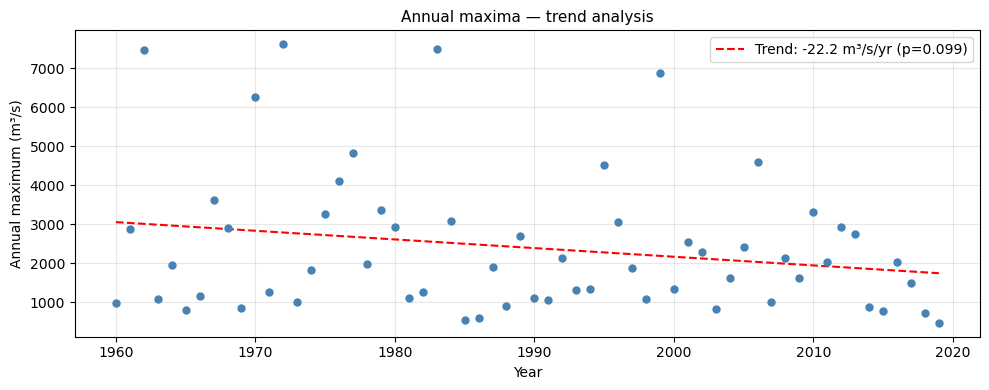

In [22]:
from scipy.stats import kendalltau, linregress

years = annual_max.index.year.values
values_am = annual_max.values

tau, p_mk = kendalltau(years, values_am)
slope, intercept, r, p_lr, _ = linregress(years, values_am)

print(f"Mann-Kendall: tau = {tau:.3f}  p = {p_mk:.3f}")
print(f"Linear trend: slope = {slope:.2f} m³/s/year  p = {p_lr:.3f}")
if p_mk < 0.05:
    print("→ Statistically significant trend detected — consider non-stationary analysis.")
else:
    print("→ No significant trend — stationary GEV/GPD is appropriate.")

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(years, values_am, s=25, color="steelblue", zorder=4)
ax.plot(years, slope * years + intercept, "r--", lw=1.5,
        label=f"Trend: {slope:.1f} m³/s/yr (p={p_lr:.3f})")
ax.set_xlabel("Year")
ax.set_ylabel("Annual maximum (m³/s)")
ax.set_title("Annual maxima — trend analysis", fontsize=11)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()